In [3]:
"""Visualization helpers for Morgan fingerprint exploration."""

from __future__ import annotations

import itertools
from collections import defaultdict
from collections.abc import Callable, Iterable, Sequence
from typing import Any, DefaultDict, Dict, List, Tuple

import rdkit
from rdkit import Chem  # type: ignore[import]
from rdkit.Chem import Draw  # type: ignore[import]
from rdkit.Chem.Draw import rdMolDraw2D  # type: ignore[import]
from stereomolgraph import StereoMolGraph
from stereomolgraph.algorithms.color_refine import color_refine_smg

DEFAULT_DISTINCT_COLORS: Sequence[Tuple[float, float, float]] = (
    (0.121, 0.466, 0.705),  # Blue
    (0.682, 0.780, 0.909),  # Light Blue
    (1.000, 0.498, 0.054),  # Orange
    (1.000, 0.733, 0.470),  # Light Orange
    (0.172, 0.627, 0.172),  # Green
    (0.596, 0.874, 0.541),  # Light Green
    (0.839, 0.152, 0.156),  # Red
    (1.000, 0.596, 0.588),  # Light Red
    (0.580, 0.403, 0.741),  # Purple
    (0.772, 0.690, 0.835),  # Light Purple
    (0.549, 0.337, 0.294),  # Brown
    (0.768, 0.611, 0.580),  # Light Brown
    (0.890, 0.466, 0.760),  # Pink
    (0.968, 0.713, 0.823),  # Light Pink
    (0.498, 0.498, 0.498),  # Gray
    (0.780, 0.780, 0.780),  # Light Gray
    (0.737, 0.741, 0.133),  # Olive
    (0.858, 0.858, 0.552),  # Light Olive
    (0.090, 0.745, 0.811),  # Cyan
    (0.619, 0.854, 0.898),  # Light Cyan
)


def smg_color_refine(
    mol: Chem.Mol,
) -> Dict[int, int]:
    mol = Chem.AddHs(mol)
    smg = StereoMolGraph.from_rdmol(mol, stereo_complete=True)
    ret: Dict[int, int] = {}
    colors = color_refine_smg(smg)

    for color, atom in zip(colors, smg.atoms):
        if smg.atom_types[atom] != 1:
            ret[atom] = int(color)
    return ret


def visualize_molecules_with_atom_labels(
    smiles_list: Iterable[str],
    *,
    fingerprint_generator: Callable[..., Dict[int, Any]] = smg_color_refine,
    show_atom_indices: bool = True,
    show_atom_bits: bool = True,
    distinct_colors: Sequence[Tuple[float, float, float]] | None = None,
    **kwargs: Any,
) -> str:
    """Render molecules with per-atom Morgan fingerprint hashes highlighted."""
    palette = tuple(distinct_colors or DEFAULT_DISTINCT_COLORS)

    mols: List[Chem.Mol] = []
    legends: List[str] = []
    highlight_atom_lists: List[List[int]] = []
    highlight_atom_colors: List[Dict[int, Tuple[float, float, float]]] = []

    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles, sanitize=False)
        mol.UpdatePropertyCache(strict=False)
        # mol = Chem.AddHs(mol)
        rdkit.Chem.GetSymmSSSR(mol)
        if mol is None:  # type: ignore[unreachable]
            raise ValueError(f"Failed to parse SMILES string: {smiles}")

        atom_hashes = fingerprint_generator(mol, **kwargs)
        unique_hashes = sorted(set(atom_hashes.values()))

        # Cycle through the palette if there are more unique hashes than colors
        colors = list(
            itertools.islice(itertools.cycle(palette), len(unique_hashes))
        )
        hash_to_color: Dict[Any, Tuple[float, float, float]] = dict(
            zip(unique_hashes, colors)
        )

        highlight_colors = {
            idx: hash_to_color[h] for idx, h in atom_hashes.items()
        }
        highlight_atoms = list(highlight_colors.keys())

        if show_atom_bits:
            hash_to_atoms: DefaultDict[int, List[int]] = defaultdict(list)
            for atom_idx, hash_val in atom_hashes.items():
                hash_to_atoms[hash_val].append(atom_idx)
            legend_parts = [
                f"{hash_val}: {','.join(str(atom) for atom in sorted(atom_ids))}"
                for hash_val, atom_ids in sorted(hash_to_atoms.items())
            ]
            legend = "\n ".join(legend_parts)
        else:
            legend = ""

        mols.append(mol)
        legends.append(legend)
        highlight_atom_lists.append(highlight_atoms)
        highlight_atom_colors.append(highlight_colors)

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.addStereoAnnotation = True
    if show_atom_indices:
        draw_options.addAtomIndices = True

    if show_atom_bits:
        draw_options.legendFraction = 0.25

    svg = Draw.MolsToGridImage(
        mols,
        molsPerRow=1,
        legends=legends,
        highlightAtomLists=highlight_atom_lists,
        highlightAtomColors=highlight_atom_colors,
        highlightBondLists=[[] for _ in mols],
        useSVG=True,
        drawOptions=draw_options,
    )
    return svg


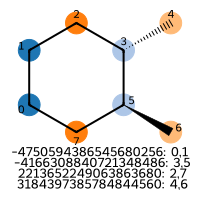

In [4]:
smiles_symmetry = [r"C1CC[C@H](C)[C@@H](C)C1"]

svg_ecfp = visualize_molecules_with_atom_labels(
    smiles_symmetry,
)
display(svg_ecfp)